# Visualize SCALP-lite Embedding

Choose a registered dataset, preprocess it, build the SCALP graph, plot, and save the embedded AnnData file.

In [1]:
from scalp_lite.notebook_utils import DATASET_REGISTRY, dataset_config, embed_dataset, load_preprocessed_data, make_estimator


selected_dataset = "zebrafish"
dataset = dataset_config(selected_dataset)

# Override defaults here when needed.
preprocess_overrides = {
    "n_top_genes": 2000,
    "max_cells": None,
    "min_cell_genes": None,
}
graph_overrides = {}

estimator = make_estimator(dataset, n_components=100, random_state=0)
input_path = dataset["input_path"]
output_path = dataset["output_path"]
batch_key = dataset["batch_key"]
label_key = dataset["label_key"]

selected_dataset, input_path, output_path, batch_key, label_key


('zebrafish',
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/cellrank-zebrafish.h5ad'),
 PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/cellrank-zebrafish-scalp.h5ad'),
 'Stage',
 'lineages')

In [2]:
adata = load_preprocessed_data(estimator, dataset, **preprocess_overrides)
adata


AnnData object with n_obs × n_vars = 2434 × 2000
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    var: 'scalp_lite_hvg_score', 'scalp_lite_selected'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed', 'X_pca'

In [3]:
graph_params = {**dataset["graph"], **graph_overrides}
adata = embed_dataset(adata, estimator, graph_params)
graph_params


{'n_neighbors': 30,
 'intra_fraction': 0.5,
 'n_inter_edges': 1,
 'assignment_quantile': 0.75,
 'hubness_correction': 'csls',
 'hubness_k': 10,
 'rank_correction': True,
 'edge_weighting': 'distance',
 'mutual_neighbors': False,
 'neighbor_mode': 'distance',
 'symmetrize': True}

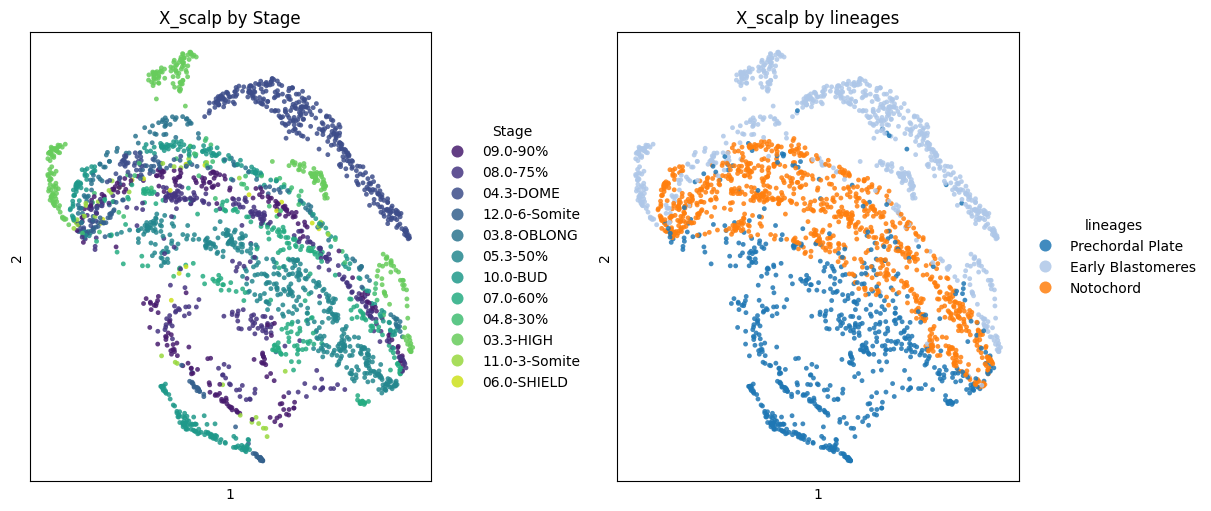

In [4]:
estimator.plot(adata, embedding_key="X_scalp");


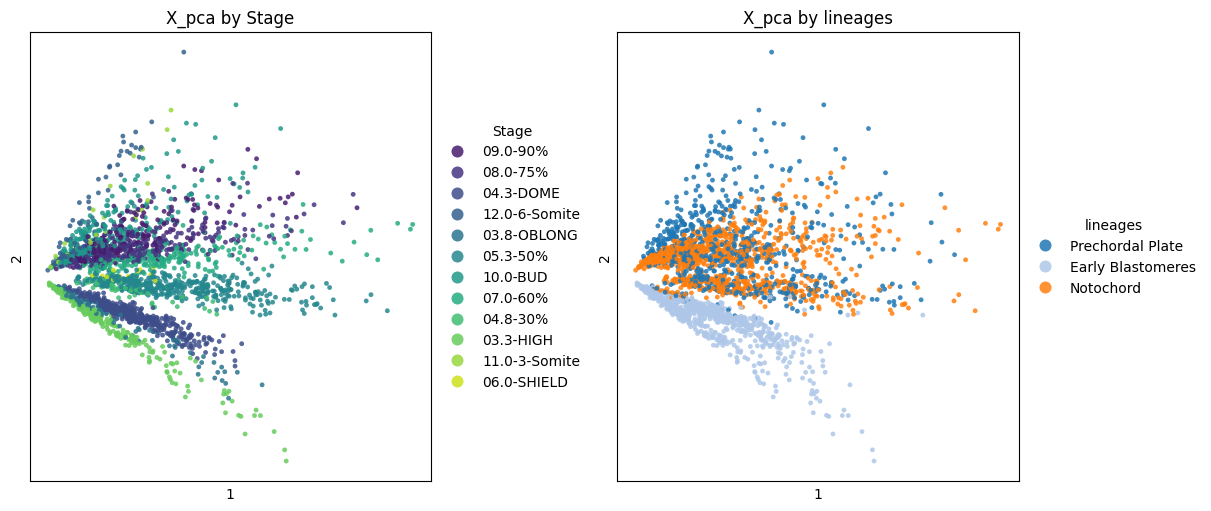

In [5]:
estimator.plot(adata, embedding_key="X_pca");


In [6]:
estimator.save(adata, output_path)
output_path


PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/ACTIVE/scalp-lite/data/cellrank-zebrafish-scalp.h5ad')